# Quantum Kernels vs Classical Kernels

Variational quantum circuits are not the only approach to quantum machine learning.

In fact, one of the most mathematically interesting approaches is something called a quantum kernel method, which this notebook goes into detail on.

This notebook explores:
- what kernels actually are
- how quantum feature maps work
- how quantum kernels compare against classical kernels
- and most importantly:
> whether quantum models are actually doing something useful or just looking impressive

This question matters a lot because modern QML research is only valuable if compared against strong classical baselines.

In [1]:
import pennylane as qml
from pennylane import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

from sklearn.metrics.pairwise import rbf_kernel

# What Is a Kernel?

At first, kernels seem weird and abstract, but the core idea is actually quite simple.

A kernel is just a way of measuring similarity between data points.

For example:
- Points close together should feel 'similar'.
- Points far apart should feel 'different'.

Instead of directly learning in the original feature space, kernel methods implicitly project data into a much higher-dimensional space where patterns may become easier to separate.

For a simpler way to imagine this, visualize trying to separate tangled wires on a table.

In 2D, it is almost impossible, but if you lift one wire upward into 3D space, suddenly separation becomes easy.

Kernel methods do something conceptually similar: they transform geometry into a space where classification becomes easier.

The famous classical example is the RBF kernel. Quantum kernels attempt to do something similar using quantum states.

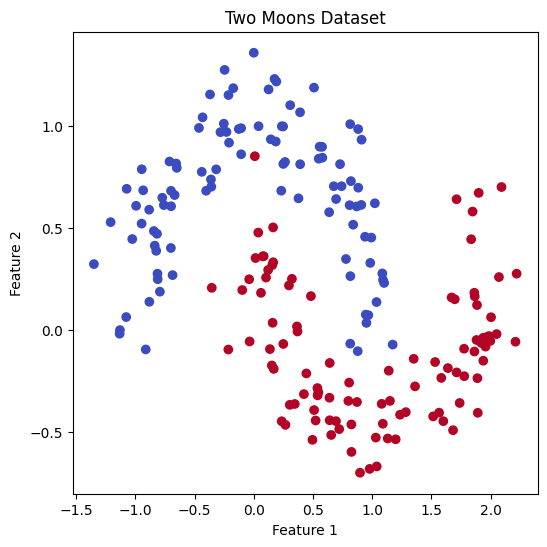

In [2]:
# Create dataset

X, y = make_moons(
    n_samples=200,
    noise=0.15,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

plt.figure(figsize=(6, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap='coolwarm'
)

plt.title("Two Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

# Quantum Feature Maps

A quantum kernel starts with something called a feature map, which takes classical data and encodes it into a quantum state.

Mathematically:

$$
x \rightarrow |\phi(x)\rangle
$$

The idea is that quantum states live in exponentially large vector spaces called Hilbert spaces.

This means even small quantum systems can represent extremely complicated geometric relationships, at least in theory.

The question is:
> do those geometric relationships actually help learning?

That is what researchers are still trying to figure out.

In [3]:
n_qubits = 2

dev = qml.device("default.qubit", wires=n_qubits)

def feature_map(x):

    qml.RY(x[0], wires=0)
    qml.RY(x[1], wires=1)

    qml.CNOT(wires=[0, 1])


@qml.qnode(dev)
def kernel_circuit(x1, x2):

    feature_map(x1)

    qml.adjoint(feature_map)(x2)

    return qml.probs(wires=[0, 1])

# What Is This Circuit Actually Doing?

This circuit measures overlap between two quantum states.

If two encoded states are very similar:
- the overlap will be high
- the kernel value becomes large

If they are very different:
- overlap becomes small
- kernel value decreases

So the kernel is effectively measuring similarity inside quantum state space.

That similarity becomes the foundation for classification.

In [4]:
def quantum_kernel(x1, x2):

    probs = kernel_circuit(x1, x2)

    return probs[0]


def compute_kernel_matrix(X1, X2):

    return np.array([
        [quantum_kernel(x1, x2) for x2 in X2]
        for x1 in X1
    ])

In [5]:
# Compute quantum kernel matrices

K_train_quantum = compute_kernel_matrix(X_train, X_train)

K_test_quantum = compute_kernel_matrix(X_test, X_train)

# Visualizing the Kernel Matrix

A kernel matrix stores pairwise similarities between every data point.

Bright regions mean points are considered similar.

Whereas dark regions mean points are considered different.

So this heatmap is effectively showing the geometry the model "believes" exists in the dataset.

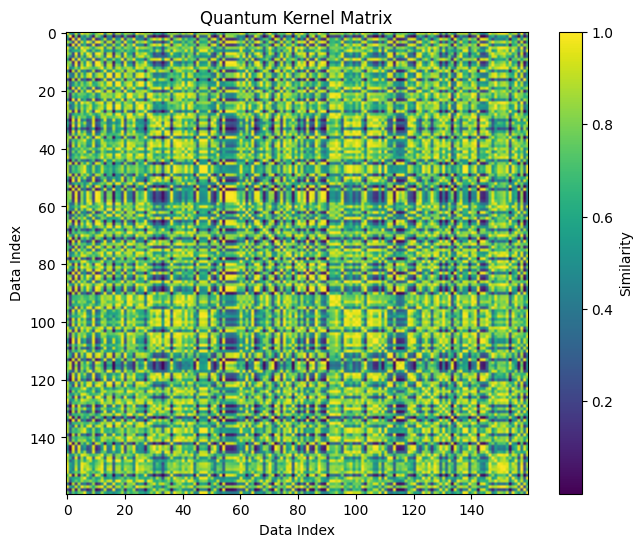

In [6]:
plt.figure(figsize=(8, 6))

plt.imshow(K_train_quantum)

plt.title("Quantum Kernel Matrix")
plt.xlabel("Data Index")
plt.ylabel("Data Index")

plt.colorbar(label="Similarity")

plt.show()

# Classical RBF Kernel

Now we compare against a classical baseline.

This is one of the most important parts of serious QML work, because without a strong classical comparison, a quantum model means very little.

The RBF kernel is one of the strongest and most widely used classical kernels, which also creates nonlinear decision boundaries using geometric similarity.

So this comparison is fairer than comparing against something weak like linear regression.

In [7]:
K_train_rbf = rbf_kernel(X_train, X_train)

K_test_rbf = rbf_kernel(X_test, X_train)

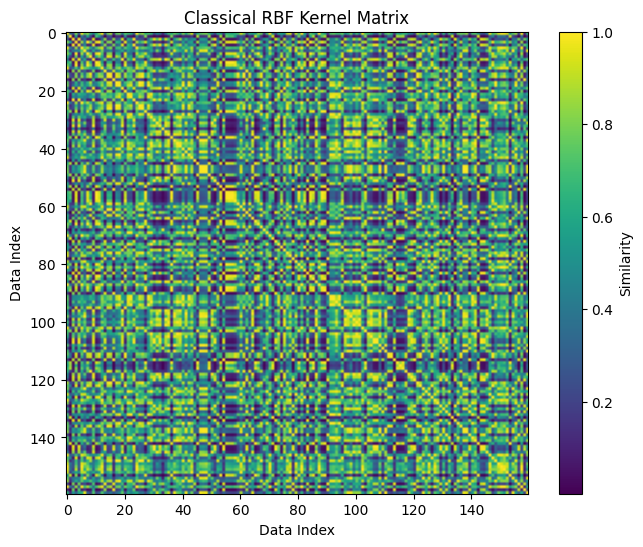

In [8]:
plt.figure(figsize=(8, 6))

plt.imshow(K_train_rbf)

plt.title("Classical RBF Kernel Matrix")
plt.xlabel("Data Index")
plt.ylabel("Data Index")

plt.colorbar(label="Similarity")

plt.show()

# Compare the Heatmaps Carefully

The structures may actually look surprisingly similar.

That is not accidental.

One of the major discoveries in recent QML research is that:
> Many quantum kernels behave similarly to strong classical kernels.

This became a huge debate in the field.

Early papers suggested quantum kernels might unlock dramatic advantages while later work showed that:
- Many quantum kernels are classically simulable
- Classical kernels often achieve similar performance
- Small quantum experiments do not necessarily imply scalability

This doesn't mean quantum ML is useless, but rather that the standards for proving advantage became much higher.

In [9]:
# Train SVM using quantum kernel

quantum_svm = SVC(kernel='precomputed')

quantum_svm.fit(K_train_quantum, y_train)

quantum_preds = quantum_svm.predict(K_test_quantum)

quantum_acc = accuracy_score(y_test, quantum_preds)

print("Quantum Kernel Accuracy:", quantum_acc)

Quantum Kernel Accuracy: 0.85


In [10]:
# Train classical RBF SVM

rbf_svm = SVC(kernel='precomputed')

rbf_svm.fit(K_train_rbf, y_train)

rbf_preds = rbf_svm.predict(K_test_rbf)

rbf_acc = accuracy_score(y_test, rbf_preds)

print("Classical RBF Accuracy:", rbf_acc)

Classical RBF Accuracy: 0.975


# Interpreting the Results

If the classical model performs similarly, it is not considered a failure; in fact, it is valuable information.

A lot of weak QML projects try to force the conclusion:
> "quantum wins."

When in reality, sometimes:
- Quantum helps
- Sometimes it doesn't
- Sometimes classical methods completely match it or even exceed it

And understanding why is the interesting part.

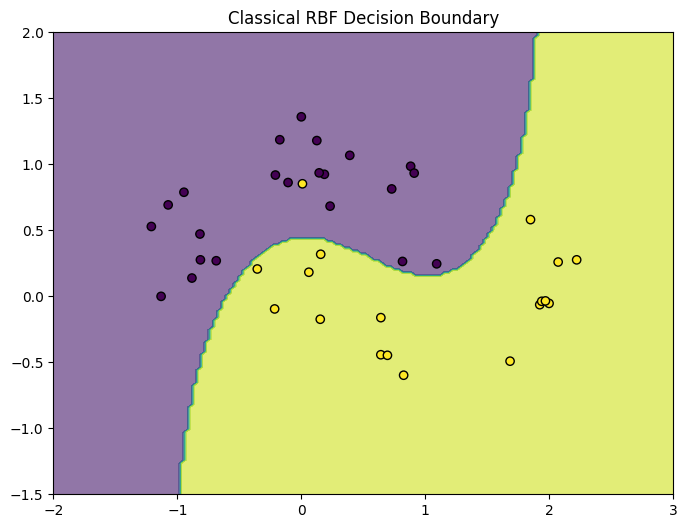

In [11]:
# Visualize predictions from classical model

xx, yy = np.meshgrid(
    np.linspace(-2, 3, 150),
    np.linspace(-1.5, 2, 150)
)

grid = np.c_[xx.ravel(), yy.ravel()]

K_grid_rbf = rbf_kernel(grid, X_train)

Z_rbf = rbf_svm.predict(K_grid_rbf)

Z_rbf = Z_rbf.reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z_rbf, alpha=0.6)

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    edgecolors='black'
)

plt.title("Classical RBF Decision Boundary")

plt.show()

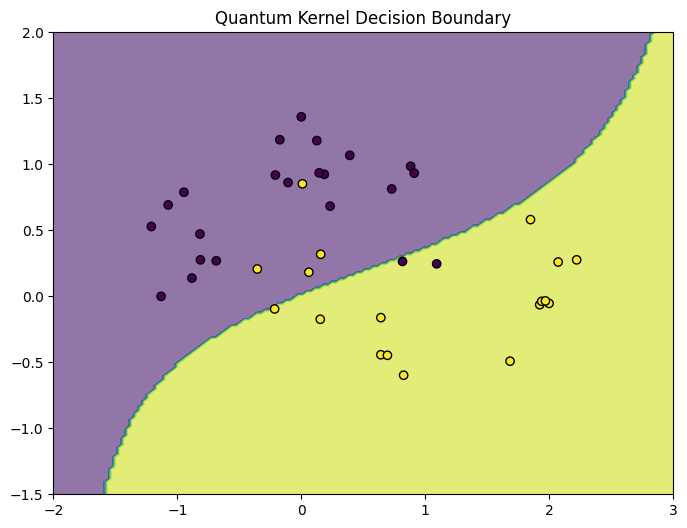

In [12]:
# Visualize predictions from quantum model

K_grid_quantum = compute_kernel_matrix(grid, X_train)

Z_quantum = quantum_svm.predict(K_grid_quantum)

Z_quantum = Z_quantum.reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z_quantum, alpha=0.6)

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    edgecolors='black'
)

plt.title("Quantum Kernel Decision Boundary")

plt.show()

# Fairness of Comparison

A fair comparison means:
- same dataset
- same train/test split
- same evaluation metric
- strong classical baseline
- same preprocessing assumptions

If you compare a carefully-tuned quantum model against a terrible classical model, then the comparison is meaningless.

This is one reason modern QML papers are much more rigorous than earlier ones.

# Where Quantum Kernels Might Help

Researchers believe quantum kernels may help when:
- Data naturally comes from quantum systems
- Feature spaces become classically intractable
- Entanglement captures useful correlations
- Classical kernels cannot efficiently reproduce the geometry

Potential domains include:
- Quantum chemistry
- Materials science
- Quantum sensor data
- Certain structured optimization problems

But proving real advantage remains difficult.

# Where Quantum Kernels Probably Don't Help

Quantum kernels are not automatically better.

In many practical datasets:
- Classical kernels work extremely well
- Quantum circuits are noisy
- Simulation overhead dominates and makes quantum circuits less feasible
- Feature maps are too shallow
- Kernels become classically approximable

This is why modern QML research increasingly focuses on:
- trainability
- inductive bias
- data structure
- scalability
- noise robustness

instead of simply saying:
> "Quantum computers are powerful."

# Final Reflection

In this notebook, you explored:
- geometric learning
- similarity measures
- feature embeddings
- Hilbert space representations
- scientific skepticism in QML

In fact, skepticism is a good thing to identify the boundaries of the field that is QML. A lot of modern QML research is not about blindly proving quantum superiority, but rather it is about carefully investigating when quantum representations differ from classical ones.

That is a much harder and more nuanced question, but also a much more interesting one.